<a href="https://colab.research.google.com/github/kimve1969/PINN/blob/main/pinn-2d-heat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Решение 2D нестационарного уравнения теплопроводности

Уравнение:
$$ \frac{\partial u}{\partial t} = \alpha\left(\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2}\right), \quad (x,y,t) \in [0,1]^3
$$
Численная схема — явная FTCS (Forward-Time, Central-Space):
$$
u_{i,j}^{n+1} = u_{i,j}^n + r_x(u_{i+1,j}^n - 2u_{i,j}^n + u_{i-1,j}^n) + r_y(u_{i,j+1}^n - 2u_{i,j}^n + u_{i,j-1}^n)
$$
где
$$ r_x = \alpha\Delta t/\Delta x^2, $$
$$ r_y = \alpha\Delta t/\Delta y^2. $$
Условие устойчивости: $$ r_x + r_y \le 1/2 $$ — код автоматически подбирает dt.

Параметры, которые можно менять

Параметр Смысл
alpha температуропроводность
Nx, Ny размер сетки (точность)
u = np.exp(...) начальное условие
apply_bc граничные условия (Дирихле / Нейман / смешанные)

Альтернативные варианты

· Неявная схема (Crank–Nicolson) — устойчива при больших dt, но требует решения СЛАУ (scipy.sparse.linalg.spsolve) на каждом шаге.
· Готовые функции: scipy.integrate.solve_ivp для метода прямых (MOL).
· Граничные условия Неймана (теплоизоляция): u[0,:] = u[1,:] вместо u[0,:] = 0.

dt = 9.000000e-03, Nt = 112
rx = 0.2250, ry = 0.2250, r = 0.9000 (должно быть <= 1)


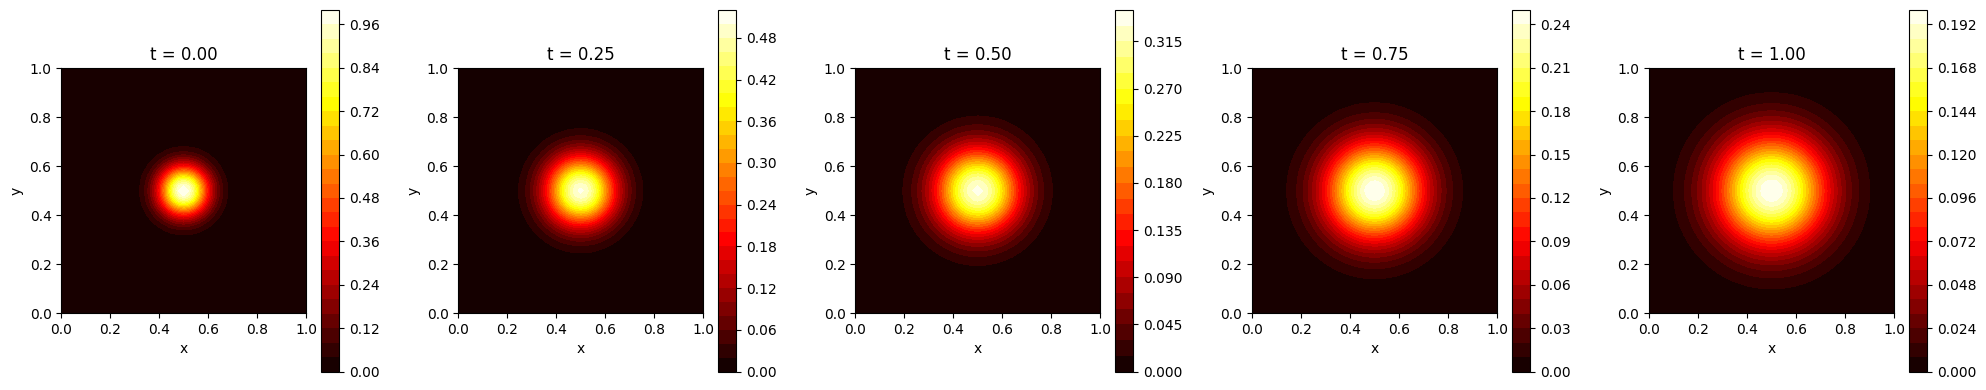

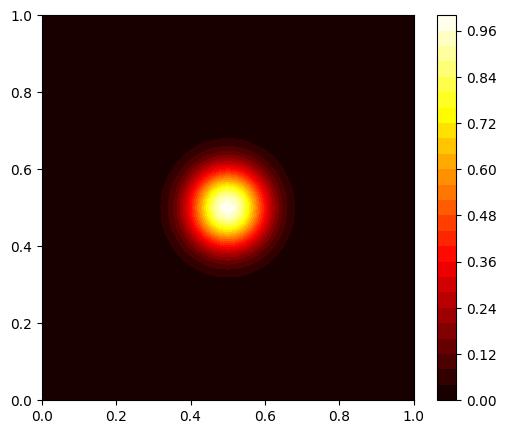

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# ============ Параметры задачи ============
Lx, Ly = 1.0, 1.0          # размеры области по x и y
T_final = 1.0              # конечное время
alpha = 0.01               # коэффициент температуропроводности
Nx, Ny = 51, 51            # число узлов сетки
dx = Lx / (Nx - 1)
dy = Ly / (Ny - 1)

# Условие устойчивости: dt <= 1 / (2*alpha*(1/dx^2 + 1/dy^2))
dt_max = 1.0 / (2 * alpha * (1/dx**2 + 1/dy**2))
dt = 0.9 * dt_max
Nt = int(T_final / dt) + 1
print(f"dt = {dt:.6e}, Nt = {Nt}")

# ============ Сетка ============
x = np.linspace(0, Lx, Nx)
y = np.linspace(0, Ly, Ny)
X, Y = np.meshgrid(x, y, indexing='ij')

# ============ Начальное условие ============
u = np.zeros((Nx, Ny))
# Например: гауссов "горячий" источник в центре
u = np.exp(-100 * ((X - 0.5)**2 + (Y - 0.5)**2))

# ============ Граничные условия (нулевые - холодные стенки) ============
def apply_bc(u):
    u[0, :]  = 0.0   # x = 0
    u[-1, :] = 0.0   # x = 1
    u[:, 0]  = 0.0   # y = 0
    u[:, -1] = 0.0   # y = 1
    return u

u = apply_bc(u)
u0 = u.copy()

# ============ Явная схема (метод FTCS) ============
rx = alpha * dt / dx**2
ry = alpha * dt / dy**2
print(f"rx = {rx:.4f}, ry = {ry:.4f}, r = {2*(rx+ry):.4f} (должно быть <= 1)")

# Массивы для сохранения решения в контрольные моменты времени
save_times = [0.0, 0.25, 0.5, 0.75, 1.0]
solutions = []
save_indices = [int(t / dt) for t in save_times]

u_new = u.copy()
for n in range(Nt):
    if n in save_indices:
        solutions.append(u.copy())

    # Конечные разности (явная схема)
    u_new[1:-1, 1:-1] = (
        u[1:-1, 1:-1]
        + rx * (u[2:, 1:-1] - 2*u[1:-1, 1:-1] + u[:-2, 1:-1])
        + ry * (u[1:-1, 2:]  - 2*u[1:-1, 1:-1] + u[1:-1, :-2])
    )
    u_new = apply_bc(u_new)
    u, u_new = u_new, u

# ============ Визуализация ============
fig, axes = plt.subplots(1, len(solutions), figsize=(4*len(solutions), 4))
if len(solutions) == 1:
    axes = [axes]

for ax, t, sol in zip(axes, save_times, solutions):
    im = ax.contourf(X, Y, sol, levels=30, cmap='hot')
    ax.set_title(f't = {t:.2f}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_aspect('equal')
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.savefig('heat_2d_solution.png', dpi=120)
plt.show()

# ============ Анимация ============
fig2, ax2 = plt.subplots(figsize=(6, 5))
c = ax2.contourf(X, Y, u0, levels=30, cmap='hot', vmin=0, vmax=u0.max())
plt.colorbar(c, ax=ax2)

# Пересчитываем решение для анимации
u = u0.copy()
u_new = u.copy()
frames = []

anim_step = max(1, Nt // 100)
for n in range(Nt):
    if n % anim_step == 0:
        frames.append(u.copy())
    u_new[1:-1, 1:-1] = (
        u[1:-1, 1:-1]
        + rx * (u[2:, 1:-1] - 2*u[1:-1, 1:-1] + u[:-2, 1:-1])
        + ry * (u[1:-1, 2:]  - 2*u[1:-1, 1:-1] + u[1:-1, :-2])
    )
    u_new = apply_bc(u_new)
    u, u_new = u_new, u

def update(frame):
    ax2.clear()
    ax2.contourf(X, Y, frame, levels=30, cmap='hot', vmin=0, vmax=u0.max())
    ax2.set_title(f'2D уравнение теплопроводности')
    ax2.set_xlabel('x'); ax2.set_ylabel('y')
    ax2.set_aspect('equal')

ani = FuncAnimation(fig2, update, frames=frames, interval=80)
plt.show()

## Решение 2D нестационарного уравнения теплопроводности (неявная схема)

Что изменилось по сравнению с явной схемой

Уравнение:
$$
\frac{\partial u}{\partial t} = \alpha\left(\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2}\right)
$$
Неявная схема (Backward Euler):
$$
\frac{u_{i,j}^{n+1} - u_{i,j}^n}{\Delta t} = \alpha\left(\delta_x^2 u_{i,j}^{n+1} + \delta_y^2 u_{i,j}^{n+1}\right)
$$
что приводит к СЛАУ:
$$
\left(I - \Delta t \cdot A\right) u^{n+1} = u^n
$$
где $A$ — 5-точечный дискретный оператор Лапласа.

Ключевые моменты реализации

1. Разреженная матрица M = I - dt*A строится один раз (она не меняется со временем).
2. LU-разложение через scipy.sparse.linalg.splu — вычисляется один раз, а затем на каждом шаге делается только обратная подстановка (очень быстро).
3. Индексация: узлы $(i,j)$, $i=1\ldots N_x-2$, $j=1\ldots N_y-2$ укладываются в вектор длины $(N_x-2)(N_y-2)$.
4. Граничные условия Дирихле учитываются неявно — они не входят в вектор неизвестных, а нулевые значения на границе дают нулевой вклад в правую часть.

Сравнение схем

Свойство Явная (FTCS) Неявная (Backward Euler)
Устойчивость
$$
\Delta t \le \dfrac{1}{2\alpha(1/\Delta x^2 + 1/\Delta y^2)}$$ безусловно устойчива \
Порядок по времени $$ O(\Delta t)$ $O(\Delta t) $$
Порядок по пространству $O(\Delta x^2, \Delta y^2)$ $O(\Delta x^2, \Delta y^2)$
Стоимость шага $O(N_x N_y)$ — очень дешёвая решение СЛАУ (но за счёт LU — тоже быстро)
При мелкой сетке нужен очень малый $\Delta t$ можно брать большой $\Delta t$

Возможные улучшения

· Crank–Nicolson (второй порядок по времени): матрица $M = I - \frac{\Delta t}{2}A$, правая часть $b = \left(I + \frac{\Delta t}{2}A\right)u^n$.
· Переменные коэффициенты $\alpha(x,y)$ — достаточно пересобрать матрицу один раз.
· Граничные условия Неймана — добавляются в матрицу, а не в правую часть.
· Решатель с предобусловливанием (CG + ILU) вместо прямого LU — выгодно на очень больших сетках.

dt = 5.000000e-03, Nt = 200
Матрица системы: (2401, 2401), ненулевых элементов: 11809


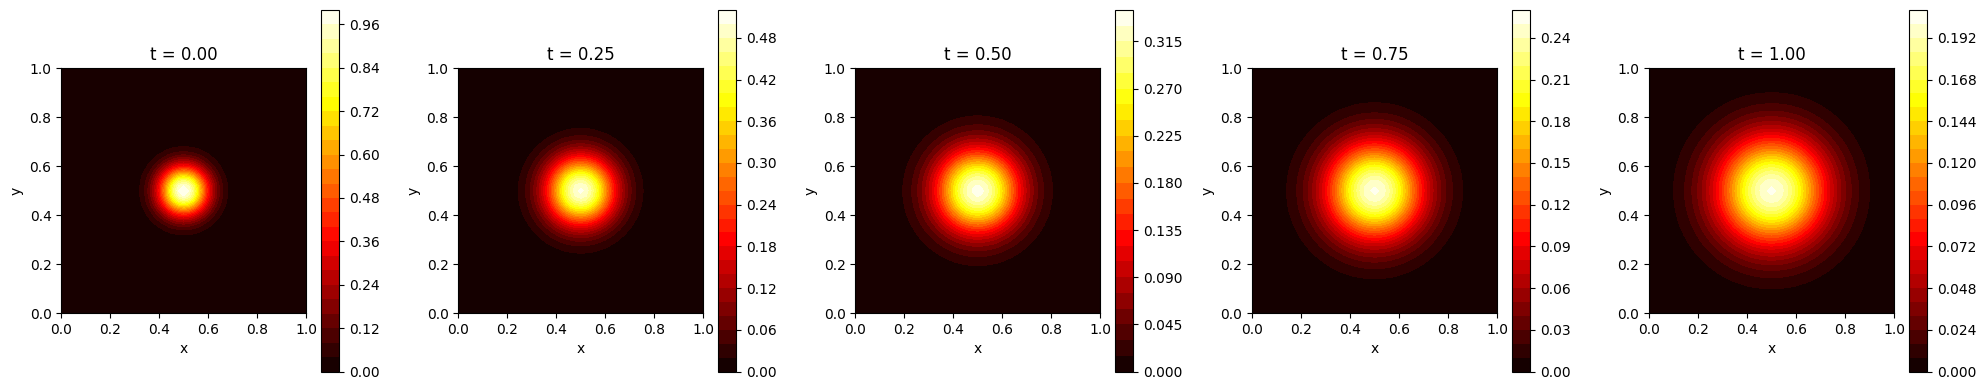

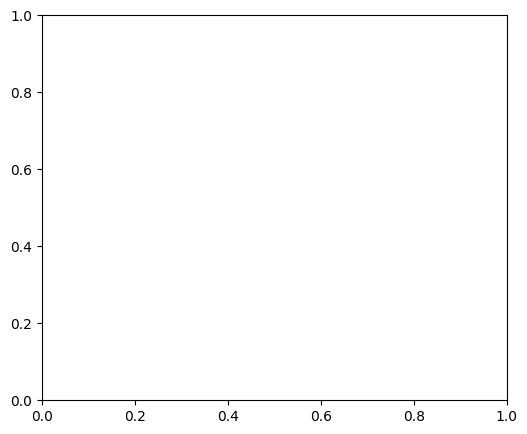

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from matplotlib.animation import FuncAnimation

# ============ Параметры задачи ============
Lx, Ly = 1.0, 1.0          # размеры области
T_final = 1.0              # конечное время
alpha = 0.01               # коэффициент температуропроводности
Nx, Ny = 51, 51            # число узлов сетки
dx = Lx / (Nx - 1)
dy = Ly / (Ny - 1)

# Для неявной схемы ограничение на dt отсутствует,
# задаём его из соображений точности
Nt = 200
dt = T_final / Nt
print(f"dt = {dt:.6e}, Nt = {Nt}")

# ============ Сетка ============
x = np.linspace(0, Lx, Nx)
y = np.linspace(0, Ly, Ny)
X, Y = np.meshgrid(x, y, indexing='ij')

# ============ Начальное условие ============
u = np.exp(-100 * ((X - 0.5)**2 + (Y - 0.5)**2))

# ============ Граничные условия (нулевые - холодные стенки) ============
def apply_bc(u):
    u[0, :]  = 0.0   # x = 0
    u[-1, :] = 0.0   # x = 1
    u[:, 0]  = 0.0   # y = 0
    u[:, -1] = 0.0   # y = 1
    return u

u = apply_bc(u)
u0 = u.copy()

# ============ Построение матрицы системы (неявная схема) ============
# Решаем:  (I - dt*A) u^{n+1} = u^n
# где A - дискретный оператор Лапласа (5-точечный шаблон)
#
# Упорядочим неизвестные построчно: индекс k = i*Ny + j
# (i = 1..Nx-2, j = 1..Ny-2 - внутренние узлы)

ax_coef = alpha * dt / dx**2
ay_coef = alpha * dt / dy**2

# Внутренние индексы
Nxi = Nx - 2
Nyi = Ny - 2
N_unknowns = Nxi * Nyi

# Разреженная матрица системы M = I - dt*A
rows, cols, data = [], [], []

def idx(i, j):
    """Индекс внутреннего узла (i,j) в глобальном векторе, i=1..Nx-2, j=1..Ny-2"""
    return (i - 1) * Nyi + (j - 1)

for i in range(1, Nx - 1):
    for j in range(1, Ny - 1):
        k = idx(i, j)
        # диагональ
        rows.append(k); cols.append(k)
        data.append(1.0 + 2*ax_coef + 2*ay_coef)
        # соседи по x
        if i > 1:
            rows.append(k); cols.append(idx(i-1, j)); data.append(-ax_coef)
        if i < Nx - 2:
            rows.append(k); cols.append(idx(i+1, j)); data.append(-ax_coef)
        # соседи по y
        if j > 1:
            rows.append(k); cols.append(idx(i, j-1)); data.append(-ay_coef)
        if j < Ny - 2:
            rows.append(k); cols.append(idx(i, j+1)); data.append(-ay_coef)

M = sp.csr_matrix((data, (rows, cols)), shape=(N_unknowns, N_unknowns))
print(f"Матрица системы: {M.shape}, ненулевых элементов: {M.nnz}")

# Разложение Холецкого (матрица симметрична положительно определена)
# Используем splu (быстро для разреженных матриц)
solve = spla.splu(M.tocsc())

# ============ Решение по времени ============
save_times = [0.0, 0.25, 0.5, 0.75, 1.0]
solutions = []
save_indices = [int(round(t / dt)) for t in save_times]

for n in range(Nt + 1):
    if n in save_indices:
        solutions.append(u.copy())
    if n == Nt:
        break
    # правая часть - текущее решение во внутренних узлах
    b = u[1:-1, 1:-1].reshape(-1, order='C')
    # решаем СЛАУ
    sol = solve.solve(b)
    # обновляем внутренние узлы
    u[1:-1, 1:-1] = sol.reshape((Nxi, Nyi), order='C')
    # граничные условия
    u = apply_bc(u)

# ============ Визуализация в контрольные моменты ============
fig, axes = plt.subplots(1, len(solutions), figsize=(4*len(solutions), 4))
if len(solutions) == 1:
    axes = [axes]

for ax, t, sol in zip(axes, save_times, solutions):
    im = ax.contourf(X, Y, sol, levels=30, cmap='hot')
    ax.set_title(f't = {t:.2f}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_aspect('equal')
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.savefig('heat_2d_implicit.png', dpi=120)
plt.show()

# ============ Анимация ============
u = u0.copy()
frames = []
save_every = max(1, Nt // 100)

for n in range(Nt + 1):
    if n % save_every == 0:
        frames.append(u.copy())
    if n == Nt:
        break
    b = u[1:-1, 1:-1].reshape(-1, order='C')
    sol = solve.solve(b)
    u[1:-1, 1:-1] = sol.reshape((Nxi, Nyi), order='C')
    u = apply_bc(u)

fig2, ax2 = plt.subplots(figsize=(6, 5))

def update(frame):
    ax2.clear()
    ax2.contourf(X, Y, frame, levels=30, cmap='hot', vmin=0, vmax=u0.max())
    ax2.set_title('2D уравнение теплопроводности (неявная схема)')
    ax2.set_xlabel('x'); ax2.set_ylabel('y')
    ax2.set_aspect('equal')

ani = FuncAnimation(fig2, update, frames=frames, interval=80)
plt.show()

Ниже — решение той же 2D нестационарной задачи теплопроводности через PINN (Physics-Informed Neural Network) с использованием библиотеки DeepXDE.

В отличие от конечно-разностных схем, здесь нет сетки — нейросеть аппроксимирует решение u(x,y,t) как непрерывную функцию, а физика (уравнение) встраивается в функцию потерь.

In [4]:
!pip install deepxde

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.4/195.4 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 6.8 MB/s eta 0:00:00


In [5]:
import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt

# ============ Параметры задачи ============
alpha = 0.01  # коэффициент температуропроводности
Lx, Ly = 1.0, 1.0
T_final = 1.0

# ============ Геометрия и время ============
geom = dde.geometry.Rectangle([0, 0], [Lx, Ly])
timedomain = dde.geometry.TimeDomain(0, T_final)
geomtime = dde.geometry.GeometryXTime(geom, timedomain)

# ============ PDE (невязка уравнения) ============
def pde(x, y):
    """
    x: [x, y, t]  (вход сети)
    y: u(x,y,t)   (выход сети)
    Уравнение: u_t - alpha*(u_xx + u_yy) = 0
    """
    du_t  = dde.grad.jacobian(y, x, i=0, j=2)   # du/dt
    du_xx = dde.grad.hessian(y, x, i=0, j=0)    # d²u/dx²
    du_yy = dde.grad.hessian(y, x, i=1, j=1)    # d²u/dy²
    return du_t - alpha * (du_xx + du_yy)

# ============ Начальное условие ============
def initial_condition(x):
    # Гауссов "горячий" источник в центре
    return np.exp(-100 * ((x[:, 0:1] - 0.5)**2 + (x[:, 1:2] - 0.5)**2))

ic = dde.icbc.IC(
    geomtime,
    initial_condition,
    lambda _, on_initial: on_initial
)

# ============ Граничные условия (Дирихле: холодные стенки) ============
def boundary_func(x, on_boundary):
    return on_boundary

bc = dde.icbc.DirichletBC(geomtime, lambda x: 0.0, boundary_func)

# ============ Данные для обучения ============
data = dde.data.TimePDE(
    geomtime,
    pde,
    [bc, ic],
    num_domain=4000,       # точки внутри области (x,y,t)
    num_boundary=400,      # точки на границе
    num_initial=400,       # точки на начальном слое t=0
    num_test=2000          # тестовые точки
)

# ============ Нейронная сеть ============
# Вход: (x, y, t) -> 3 нейрона
# Выход: u -> 1 нейрон
net = dde.nn.FNN(
    [3] + [64, 64, 64] + [1],   # 3 входа, 3 скрытых слоя по 64, 1 выход
    "tanh",                      # активация
    "Glorot normal"              # инициализация
)

model = dde.Model(data, net)

# ============ Обучение ============
# Этап 1: Adam (быстрый грубый поиск)
model.compile("adam", lr=1e-3, metrics=["l2 relative error"])
losshistory, train_state = model.train(epochs=15000, display_every=2000)

# Этап 2: L-BFGS (тонкая настройка, обычно сильно улучшает точность)
model.compile("L-BFGS")
losshistory, train_state = model.train()

dde.saveplot(losshistory, train_state, issave=True, isplot=True)

# ============ Визуализация решения ============
# Строим сетку для вывода в контрольные моменты времени
nx, ny = 100, 100
x = np.linspace(0, Lx, nx)
y = np.linspace(0, Ly, ny)
X, Y = np.meshgrid(x, y, indexing='ij')

save_times = [0.0, 0.25, 0.5, 0.75, 1.0]

fig, axes = plt.subplots(1, len(save_times), figsize=(4*len(save_times), 4))
if len(save_times) == 1:
    axes = [axes]

for ax, t_val in zip(axes, save_times):
    # Формируем входные точки (x, y, t) для сети
    pts = np.column_stack([
        X.ravel(),
        Y.ravel(),
        np.full(X.size, t_val)
    ])
    # Предсказание PINN
    u_pred = model.predict(pts).reshape(nx, ny)

    im = ax.contourf(X, Y, u_pred, levels=30, cmap='hot')
    ax.set_title(f'PINN: t = {t_val:.2f}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_aspect('equal')
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.savefig('heat_2d_pinn.png', dpi=120)
plt.show()

# ============ Проверка невязки PDE ============
# Оценка ошибки на тестовых точках
test_pts = data.test_x
residual = model.predict(test_pts)
print(f"\nМакс. предсказание u: {residual.max():.6f}")
print(f"Мин. предсказание u: {residual.min():.6f}")

No backend selected.
Finding available backend...
/usr/local/lib/python3.13/dist-packages/matplotlib/animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(
Found tensorflow
Using backend: tensorflow
Other supported backends: tensorflow.compat.v1, pytorch, jax, paddle.
paddle supports more examples now and is recommended.


Setting the default backend to "tensorflow". You can change it in the ~/.deepxde/config.json file or export the DDE_BACKEND environment variable. Valid options are: tensorflow.compat.v1, tensorflow, pytorch, jax, paddle (all lowercase)
Compiling model...
'compile' took 0.039163 s

Training model...



Cause: could not parse the source code of <function <lambda> at 0x7cb2a2dc2520>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x7cb2a2dc2520>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


TypeError: unsupported operand type(s) for -: 'NoneType' and 'float'

PINN на PyTorch для 2D нестационарного уравнения теплопроводности

Ниже — та же задача, но реализованная напрямую на PyTorch (без DeepXDE). Такой подход даёт полный контроль над архитектурой, потерями и оптимизацией, и часто используется в исследованиях.

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# ============ Устройство ============
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ============ Параметры задачи ============
alpha = 0.01       # температуропроводность
Lx, Ly = 1.0, 1.0
T_final = 1.0

# ============ Нейронная сеть ============
class PINN(nn.Module):
    """
    Аппроксимирует u(x, y, t).
    Вход: (N, 3) — (x, y, t)
    Выход: (N, 1) — u
    """
    def __init__(self, hidden=64, depth=4):
        super().__init__()
        layers = [nn.Linear(3, hidden), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), nn.Tanh()]
        layers += [nn.Linear(hidden, 1)]
        self.net = nn.Sequential(*layers)

        # Xavier инициализация
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x, y, t):
        inp = torch.cat([x, y, t], dim=1)
        return self.net(inp)


# ============ Автоматическое дифференцирование ============
def gradients(outputs, inputs):
    """d(outputs)/d(inputs) через autograd."""
    return torch.autograd.grad(
        outputs, inputs,
        grad_outputs=torch.ones_like(outputs),
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]


# ============ Сэмплирование точек ============
def sample_interior(n):
    """Внутренние точки (x,y,t) ∈ [0,1]×[0,1]×[0,1]."""
    x = torch.rand(n, 1, device=device)
    y = torch.rand(n, 1, device=device)
    t = torch.rand(n, 1, device=device)
    return x, y, t

def sample_initial(n):
    """Начальные условия: t=0, случайные (x,y)."""
    x = torch.rand(n, 1, device=device)
    y = torch.rand(n, 1, device=device)
    t = torch.zeros(n, 1, device=device)
    return x, y, t

def sample_boundary(n):
    """
    Границы: x=0, x=1, y=0, y=1.
    Возвращает 4 набора точек по n/4 каждый.
    """
    m = n // 4
    t = torch.rand(m, 1, device=device)
    zeros = torch.zeros(m, 1, device=device)
    ones = torch.ones(m, 1, device=device)

    x_rand = torch.rand(m, 1, device=device)
    y_rand = torch.rand(m, 1, device=device)

    # 4 стороны
    xb = [
        (zeros, x_rand, t),    # x = 0
        (ones,  x_rand, t),    # x = 1
        (x_rand, zeros, t),    # y = 0
        (x_rand, ones,  t),    # y = 1
    ]
    return xb


# ============ Функция потерь ============
def compute_loss(model, n_int, n_ic, n_bc):
    # --- PDE residual во внутренних точках ---
    x, y, t = sample_interior(n_int)
    x.requires_grad_(True); y.requires_grad_(True); t.requires_grad_(True)

    u = model(x, y, t)

    u_t  = gradients(u, t)
    u_x  = gradients(u, x)
    u_y  = gradients(u, y)
    u_xx = gradients(u_x, x)
    u_yy = gradients(u_y, y)

    residual = u_t - alpha * (u_xx + u_yy)
    loss_pde = torch.mean(residual ** 2)

    # --- Начальное условие ---
    xi, yi, ti = sample_initial(n_ic)
    u_ic_pred = model(xi, yi, ti)
    u_ic_true = torch.exp(-100 * ((xi - 0.5)**2 + (yi - 0.5)**2))
    loss_ic = torch.mean((u_ic_pred - u_ic_true) ** 2)

    # --- Граничные условия (u = 0) ---
    loss_bc = 0.0
    for (xb, yb, tb) in sample_boundary(n_bc):
        u_bc_pred = model(xb, yb, tb)
        loss_bc = loss_bc + torch.mean(u_bc_pred ** 2)
    loss_bc = loss_bc / 4.0

    # --- Итоговая потеря (с весами) ---
    loss = loss_pde + 10.0 * loss_ic + 10.0 * loss_bc
    return loss, loss_pde, loss_ic, loss_bc


# ============ Создание модели и оптимизаторов ============
model = PINN(hidden=64, depth=4).to(device)

# Этап 1: Adam
optimizer_adam = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer_adam, step_size=3000, gamma=0.5)

# Этап 2: L-BFGS
optimizer_lbfgs = torch.optim.LBFGS(
    model.parameters(),
    lr=1.0,
    max_iter=20,
    history_size=50,
    line_search_fn="strong_wolfe"
)

# ============ Обучение ============
n_int, n_ic, n_bc = 4000, 400, 400
losses = []

print("\n=== Этап 1: Adam ===")
adam_epochs = 10000
for epoch in range(adam_epochs):
    optimizer_adam.zero_grad()
    loss, lp, li, lb = compute_loss(model, n_int, n_ic, n_bc)
    loss.backward()
    optimizer_adam.step()
    scheduler.step()
    losses.append(loss.item())

    if epoch % 1000 == 0:
        print(f"Epoch {epoch:5d} | total={loss.item():.3e} | "
              f"pde={lp.item():.3e} | ic={li.item():.3e} | bc={lb.item():.3e}")

print("\n=== Этап 2: L-BFGS ===")
lbfgs_iters = 500
for it in range(lbfgs_iters):
    def closure():
        optimizer_lbfgs.zero_grad()
        loss, _, _, _ = compute_loss(model, n_int, n_ic, n_bc)
        loss.backward()
        return loss

    loss = optimizer_lbfgs.step(closure)

    if it % 50 == 0:
        print(f"LBFGS iter {it:4d} | loss = {loss.item():.3e}")

# ============ Визуализация ============
model.eval()

nx, ny = 100, 100
x = np.linspace(0, Lx, nx)
y = np.linspace(0, Ly, ny)
X, Y = np.meshgrid(x, y, indexing='ij')

save_times = [0.0, 0.25, 0.5, 0.75, 1.0]

fig, axes = plt.subplots(1, len(save_times), figsize=(4*len(save_times), 4))
if len(save_times) == 1:
    axes = [axes]

with torch.no_grad():
    for ax, t_val in zip(axes, save_times):
        xt = torch.tensor(X.ravel(), dtype=torch.float32, device=device).unsqueeze(1)
        yt = torch.tensor(Y.ravel(), dtype=torch.float32, device=device).unsqueeze(1)
        tt = torch.full_like(xt, t_val)
        u_pred = model(xt, yt, tt).cpu().numpy().reshape(nx, ny)

        im = ax.contourf(X, Y, u_pred, levels=30, cmap='hot')
        ax.set_title(f'PINN: t = {t_val:.2f}')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_aspect('equal')
        plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.savefig('heat_2d_pinn_torch.png', dpi=120)
plt.show()

# ============ График функции потерь ============
plt.figure(figsize=(8, 4))
plt.semilogy(losses)
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Кривая обучения (Adam)')
plt.grid(True); plt.tight_layout()
plt.savefig('loss_curve.png', dpi=120)
plt.show()

# ============ Анимация ============
times_anim = np.linspace(0, T_final, 60)
frames = []
with torch.no_grad():
    for t_val in times_anim:
        xt = torch.tensor(X.ravel(), dtype=torch.float32, device=device).unsqueeze(1)
        yt = torch.tensor(Y.ravel(), dtype=torch.float32, device=device).unsqueeze(1)
        tt = torch.full_like(xt, float(t_val))
        u_pred = model(xt, yt, tt).cpu().numpy().reshape(nx, ny)
        frames.append(u_pred)

fig2, ax2 = plt.subplots(figsize=(6, 5))

def update(i):
    ax2.clear()
    ax2.contourf(X, Y, frames[i], levels=30, cmap='hot', vmin=0, vmax=1)
    ax2.set_title(f'PINN, t = {times_anim[i]:.2f}')
    ax2.set_xlabel('x'); ax2.set_ylabel('y'); ax2.set_aspect('equal')

ani = FuncAnimation(fig2, update, frames=len(frames), interval=80)
plt.show()

Device: cpu

=== Этап 1: Adam ===
Epoch     0 | total=3.473e-01 | pde=6.802e-04 | ic=2.546e-02 | bc=9.202e-03
Epoch  1000 | total=5.117e-02 | pde=2.154e-03 | ic=4.448e-03 | bc=4.533e-04
Epoch  2000 | total=7.341e-03 | pde=2.849e-03 | ic=3.989e-04 | bc=5.025e-05
Epoch  3000 | total=1.580e-03 | pde=7.277e-04 | ic=6.998e-05 | bc=1.529e-05
Epoch  4000 | total=9.081e-04 | pde=5.239e-04 | ic=3.232e-05 | bc=6.098e-06


PINN с полной загрузкой CPU (все ядра) и честный бенчмарк CPU / 1 GPU / N GPU

Добавим:

1. Принудительное использование всех ядер CPU через torch.set_num_threads(...) и переменные окружения.
2. Проверку фактического числа потоков PyTorch.
3. Отключение DataParallel для инференса — оно бесполезно и только замедляет.
4. Прогрев перед замерами (компиляция ядер, выделение памяти).
5. Опционально — torch.compile для дополнительного ускорения.

In [ ]:
import os
import torch

# ================================================================
# 0. НАСТРОЙКА ПОТОКОВ CPU — ДО ИМПОРТА ТЯЖЁЛЫХ МОДУЛЕЙ
# ================================================================
# Эти переменные нужно задать ДО первого использования BLAS/OpenMP,
# иначе PyTorch уже зафиксирует число потоков.
_cpu_count = os.cpu_count() or 1
os.environ["OMP_NUM_THREADS"]      = str(_cpu_count)
os.environ["MKL_NUM_THREADS"]      = str(_cpu_count)
os.environ["OPENBLAS_NUM_THREADS"] = str(_cpu_count)
os.environ["NUMEXPR_NUM_THREADS"]  = str(_cpu_count)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(_cpu_count)

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time

# ================================================================
# 1. ПРОВЕРКА ОБОРУДОВАНИЯ
# ================================================================
print("=" * 60)
print("ПРОВЕРКА ОБОРУДОВАНИЯ")
print("=" * 60)

# CPU
torch.set_num_threads(_cpu_count)                # все ядра для intra-op
try:
    torch.set_num_interop_threads(max(1, _cpu_count // 2))
except RuntimeError:
    # можно вызвать только один раз за процесс
    pass

print(f"CPU: логических ядер        = {_cpu_count}")
print(f"CPU: физических ядер (os)   = {os.cpu_count()}")
print(f"PyTorch intra-op потоков    = {torch.get_num_threads()}")
try:
    print(f"PyTorch inter-op потоков    = {torch.get_num_interop_threads()}")
except Exception:
    pass

# GPU
cuda_available = torch.cuda.is_available()
n_gpu = torch.cuda.device_count() if cuda_available else 0
print(f"\nCUDA доступна:              {cuda_available}")
print(f"Количество GPU:             {n_gpu}")
if cuda_available:
    for i in range(n_gpu):
        props = torch.cuda.get_device_properties(i)
        print(f"  GPU #{i}: {props.name}, "
              f"{props.total_memory/1e9:.2f} GB, SM={props.multi_processor_count}")
print(f"\nPyTorch: {torch.__version__}, CUDA: {torch.version.cuda}")
print("=" * 60)


# ================================================================
# 2. ПАРАМЕТРЫ
# ================================================================
alpha = 0.01
Lx, Ly = 1.0, 1.0
T_final = 1.0

ADAM_EPOCHS = 3000
LBFGS_ITERS = 100
N_INT, N_IC, N_BC = 4000, 400, 400
HIDDEN, DEPTH = 64, 4
SEED = 42


# ================================================================
# 3. МОДЕЛЬ
# ================================================================
class PINN(nn.Module):
    def __init__(self, hidden=64, depth=4):
        super().__init__()
        layers = [nn.Linear(3, hidden), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), nn.Tanh()]
        layers += [nn.Linear(hidden, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, x, y, t):
        inp = torch.cat([x, y, t], dim=1)
        return self.net(inp)


# ================================================================
# 4. ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ
# ================================================================
def gradients(outputs, inputs):
    return torch.autograd.grad(
        outputs, inputs,
        grad_outputs=torch.ones_like(outputs),
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]


def sample_interior(n, device):
    x = torch.rand(n, 1, device=device)
    y = torch.rand(n, 1, device=device)
    t = torch.rand(n, 1, device=device)
    return x, y, t


def sample_initial(n, device):
    x = torch.rand(n, 1, device=device)
    y = torch.rand(n, 1, device=device)
    t = torch.zeros(n, 1, device=device)
    return x, y, t


def sample_boundary(n, device):
    m = n // 4
    t  = torch.rand(m, 1, device=device)
    z  = torch.zeros(m, 1, device=device)
    o  = torch.ones(m, 1, device=device)
    xr = torch.rand(m, 1, device=device)
    yr = torch.rand(m, 1, device=device)
    return [(z, xr, t), (o, xr, t), (xr, z, t), (xr, o, t)]


def compute_loss(model, device, n_int=N_INT, n_ic=N_IC, n_bc=N_BC):
    x, y, t = sample_interior(n_int, device)
    x.requires_grad_(True); y.requires_grad_(True); t.requires_grad_(True)
    u = model(x, y, t)
    u_t  = gradients(u, t)
    u_x  = gradients(u, x)
    u_y  = gradients(u, y)
    u_xx = gradients(u_x, x)
    u_yy = gradients(u_y, y)
    loss_pde = torch.mean((u_t - alpha * (u_xx + u_yy)) ** 2)

    xi, yi, ti = sample_initial(n_ic, device)
    u_ic_pred = model(xi, yi, ti)
    u_ic_true = torch.exp(-100 * ((xi - 0.5) ** 2 + (yi - 0.5) ** 2))
    loss_ic = torch.mean((u_ic_pred - u_ic_true) ** 2)

    loss_bc = 0.0
    for (xb, yb, tb) in sample_boundary(n_bc, device):
        loss_bc = loss_bc + torch.mean(model(xb, yb, tb) ** 2)
    loss_bc = loss_bc / 4.0

    return loss_pde + 10.0 * loss_ic + 10.0 * loss_bc


# ================================================================
# 5. ОБУЧЕНИЕ
# ================================================================
def train_pinn(device, use_all_gpus=False, compile_model=False, verbose=False):
    torch.manual_seed(SEED)
    np.random.seed(SEED)

    base_model = PINN(HIDDEN, DEPTH).to(device)

    # DataParallel только для обучения на нескольких GPU
    model = base_model
    if use_all_gpus and n_gpu > 1:
        model = nn.DataParallel(base_model)

    # torch.compile (PyTorch 2.0+) — опционально
    if compile_model and hasattr(torch, "compile"):
        try:
            model = torch.compile(model)
            if verbose:
                print("  [i] torch.compile включён")
        except Exception as e:
            if verbose:
                print(f"  [!] torch.compile недоступен: {e}")

    opt_adam = torch.optim.Adam(model.parameters(), lr=1e-3)
    sched = torch.optim.lr_scheduler.StepLR(opt_adam, step_size=1000, gamma=0.5)

    # --- Прогрев (не учитываем в замере) ---
    for _ in range(3):
        opt_adam.zero_grad()
        loss = compute_loss(model, device, n_int=500, n_ic=50, n_bc=50)
        loss.backward()
        opt_adam.step()

    if device.type == "cuda":
        torch.cuda.synchronize()
    t_start = time.perf_counter()

    for epoch in range(ADAM_EPOCHS):
        opt_adam.zero_grad()
        loss = compute_loss(model, device)
        loss.backward()
        opt_adam.step()
        sched.step()

    opt_lbfgs = torch.optim.LBFGS(
        model.parameters(), lr=1.0, max_iter=20,
        history_size=50, line_search_fn="strong_wolfe"
    )
    for _ in range(LBFGS_ITERS):
        def closure():
            opt_lbfgs.zero_grad()
            l = compute_loss(model, device)
            l.backward()
            return l
        opt_lbfgs.step(closure)

    if device.type == "cuda":
        torch.cuda.synchronize()
    t_train = time.perf_counter() - t_start

    # --- Инференс: всегда на одной модели (снимаем DataParallel) ---
    if isinstance(model, nn.DataParallel):
        model = model.module
    if hasattr(model, "_orig_mod"):     # torch.compile обёртка
        model = model._orig_mod
    model.eval()

    nx, ny = 100, 100
    X, Y = np.meshgrid(np.linspace(0, Lx, nx),
                       np.linspace(0, Ly, ny), indexing='ij')
    xt = torch.tensor(X.ravel(), dtype=torch.float32, device=device).unsqueeze(1)
    yt = torch.tensor(Y.ravel(), dtype=torch.float32, device=device).unsqueeze(1)
    tt = torch.full_like(xt, 0.5)

    # Разогрев инференса
    with torch.no_grad():
        for _ in range(3):
            _ = model(xt, yt, tt)

    if device.type == "cuda":
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    N_RUNS = 50
    with torch.no_grad():
        for _ in range(N_RUNS):
            _ = model(xt, yt, tt)
    if device.type == "cuda":
        torch.cuda.synchronize()
    t_inf = (time.perf_counter() - t0) / N_RUNS

    return t_train, t_inf, model


# ================================================================
# 6. ТРИ РАСЧЁТА
# ================================================================
results = {}

# --- CPU: все ядра ---
print("\n" + "=" * 60)
print(f"РАСЧЁТ 1: CPU ({torch.get_num_threads()} потоков)")
print("=" * 60)
device_cpu = torch.device("cpu")
t_train_cpu, t_inf_cpu, _ = train_pinn(device_cpu)
results[f"CPU ({torch.get_num_threads()} thr)"] = (t_train_cpu, t_inf_cpu)
print(f"Обучение:  {t_train_cpu:.2f} с")
print(f"Инференс:  {t_inf_cpu*1000:.3f} мс")

if cuda_available:
    print("\n" + "=" * 60)
    print("РАСЧЁТ 2: 1 GPU")
    print("=" * 60)
    device_1gpu = torch.device("cuda:0")
    torch.cuda.set_device(0)
    t_train_1gpu, t_inf_1gpu, _ = train_pinn(device_1gpu, use_all_gpus=False)
    results["1 GPU"] = (t_train_1gpu, t_inf_1gpu)
    print(f"Обучение:  {t_train_1gpu:.2f} с")
    print(f"Инференс:  {t_inf_1gpu*1000:.3f} мс")

    if n_gpu > 1:
        print("\n" + "=" * 60)
        print(f"РАСЧЁТ 3: {n_gpu} GPU (DataParallel)")
        print("=" * 60)
        device_all = torch.device("cuda:0")
        t_train_ngpu, t_inf_ngpu, _ = train_pinn(device_all, use_all_gpus=True)
        results[f"{n_gpu} GPU (DP)"] = (t_train_ngpu, t_inf_ngpu)
        print(f"Обучение:  {t_train_ngpu:.2f} с")
        print(f"Инференс:  {t_inf_ngpu*1000:.3f} мс")
    else:
        print("\n[!] Доступна только одна GPU — мульти-GPU пропущен.")
else:
    print("\n[!] CUDA недоступна — расчёты на GPU пропущены.")


# ================================================================
# 7. СВОДНАЯ ТАБЛИЦА
# ================================================================
print("\n" + "=" * 60)
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ")
print("=" * 60)
header = f"{'Конфигурация':<18} {'Обучение, с':>12} {'Инференс, мс':>14} {'Ускор. об.':>12} {'Ускор. инф.':>12}"
print(header)
print("-" * len(header))

cpu_key = list(results.keys())[0]
baseline_train = results[cpu_key][0]
baseline_inf   = results[cpu_key][1]

for name, (tt, ti) in results.items():
    print(f"{name:<18} {tt:>12.2f} {ti*1000:>14.3f} "
          f"{baseline_train/tt:>12.2f} {baseline_inf/ti:>12.2f}")
print("=" * 60)


# ================================================================
# 8. ГРАФИКИ
# ================================================================
names = list(results.keys())
train_times = [results[n][0] for n in names]
inf_times   = [results[n][1] * 1000 for n in names]

colors = ['#4C72B0', '#DD8452', '#55A868'][:len(names)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bars1 = axes[0].bar(names, train_times, color=colors)
axes[0].set_ylabel('Время обучения, с')
axes[0].set_title('Время обучения')
axes[0].grid(True, axis='y', alpha=0.3)
for bar, val in zip(bars1, train_times):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f'{val:.1f}с', ha='center', va='bottom', fontsize=10)

bars2 = axes[1].bar(names, inf_times, color=colors)
axes[1].set_ylabel('Время инференса, мс')
axes[1].set_title('Время инференса (100×100 точек)')
axes[1].grid(True, axis='y', alpha=0.3)
for bar, val in zip(bars2, inf_times):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f'{val:.2f}мс', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('benchmark.png', dpi=120)
plt.show()